In [10]:
# 安裝套件
%pip install --upgrade pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


🔴 錄製中：100.0% [400/400]


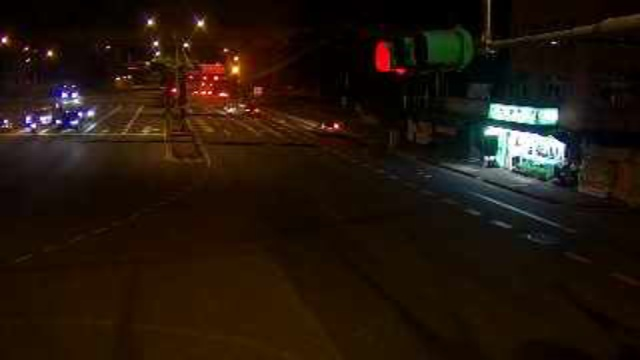

✅ 錄製結束，存儲於: c:\Users\cowri\OneDrive\桌面\carCounter\origin.mp4


In [4]:
# 錄製影片素材
import cv2
import os
import time
from datetime import datetime
from dotenv import load_dotenv
from IPython.display import clear_output, display, Image

load_dotenv()

os.environ["OPENCV_FFMPEG_CAPTURE_OPTIONS"] = "timeout;10000000|rw_timeout;10000000"

# 參數設定
CCTV_URL = os.environ["CCTV_URL"]
RECORD_SECONDS = 20
FPS = 20.0

# 建立儲存路徑
save_path = "origin.mp4"

# 開啟串流
cap = cv2.VideoCapture(CCTV_URL)

if not cap.isOpened():
    print(f"❌ 無法開啟串流 {CCTV_URL}")
else:
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  or 1280
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 720
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(save_path, fourcc, FPS, (width, height))

    print(f"🚀 開始錄製純影片...")
    print(f"📂 儲存路徑: {save_path}")
    print(f"⏱️  預計時長: {RECORD_SECONDS} 秒")

    TOTAL_FRAMES = int(RECORD_SECONDS * FPS)
    frame_count = 0

    try:
        while frame_count < TOTAL_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ 串流暫時中斷，重試中...")
                time.sleep(1)
                continue

            out.write(frame)
            frame_count += 1

            if frame_count % int(FPS) == 0:
                clear_output(wait=True)
                pct = (frame_count / TOTAL_FRAMES) * 100
                print(f"🔴 錄製中：{pct:.1f}% [{frame_count}/{TOTAL_FRAMES}]")
                resize_frame = cv2.resize(frame, (640, 360))
                _, encoded_img = cv2.imencode('.jpg', resize_frame)
                display(Image(data=encoded_img.tobytes()))

    except KeyboardInterrupt:
        print("\n🛑 手動中斷錄製")

    finally:
        cap.release()
        out.release()
        print(f"✅ 錄製結束，存儲於: {os.path.abspath(save_path)}")

In [6]:
# 上傳影片並取得標註、計數
import cv2
import os
import base64
import json
import numpy as np
from collections import defaultdict
from dotenv import load_dotenv
from inference_sdk import InferenceHTTPClient
from inference_sdk.webrtc import VideoFileSource, StreamConfig, VideoMetadata

load_dotenv()

# --- 初始化 ---
client = InferenceHTTPClient.init(
    api_url="https://serverless.roboflow.com",
    api_key=os.environ["ROBOFLOW_API_KEY"],
)

source = VideoFileSource("origin.mp4", realtime_processing=False)

VIDEO_OUTPUT = "annotated_image"
DATA_OUTPUTS = ["predictions", "annotated_image"]

config = StreamConfig(
    stream_output=[],
    data_output=DATA_OUTPUTS,
    requested_plan="webrtc-gpu-medium",
    requested_region="us",
)

session = client.webrtc.stream(
    source=source,
    workflow="carcounter",
    workspace=os.environ["ROBOFLOW_WORKSPACE"],
    image_input="image",
    config=config,
)

# --- 狀態 ---
frames = []
class_ids = defaultdict(set)   # {class_name: {tracker_id, ...}}


# --- 回呼函式 ---
@session.on_data()
def on_data(data: dict, metadata: VideoMetadata):
    global class_ids

    raw_predictions = data.get("predictions", [])

    # 將各種格式統一解析為 list
    predictions_list = []
    if isinstance(raw_predictions, dict):
        predictions_list = raw_predictions.get("predictions", [])
    elif isinstance(raw_predictions, str):
        try:
            parsed = json.loads(raw_predictions)
            predictions_list = parsed.get("predictions", []) if isinstance(parsed, dict) else parsed
        except json.JSONDecodeError:
            print("警告：無法解析 predictions 字串")
    elif isinstance(raw_predictions, list):
        predictions_list = raw_predictions

    # 計數邏輯（直接從 prediction 取 class，動態累計每個類別）
    for pred in predictions_list:
        if not isinstance(pred, dict):
            continue
        track_id = pred.get("tracker_id")
        y_center = pred.get("y", 0)
        vtype = pred.get("class")
        if track_id is None or vtype is None or y_center <= 60:
            continue
        if any(track_id in ids for ids in class_ids.values()):
            continue
        class_ids[vtype].add(track_id)
        total = sum(len(ids) for ids in class_ids.values())
        print(f"【偵測成功】ID: {track_id} | 類型: {vtype} | 總量: {total}")

    # 影像處理
    if VIDEO_OUTPUT in data:
        img_data = base64.b64decode(data[VIDEO_OUTPUT]["value"])
        img = cv2.imdecode(np.frombuffer(img_data, np.uint8), cv2.IMREAD_COLOR)

        cv2.line(img, (0, 60), (img.shape[1], 60), (255, 255, 0), 1)
        total = sum(len(ids) for ids in class_ids.values())
        cv2.putText(img, f"Total: {total}", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        y = 38
        for cls_name, ids in sorted(class_ids.items()):
            cv2.putText(img, f"{cls_name}: {len(ids)}",
                        (10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
            y += 18

        timestamp_ms = metadata.pts * metadata.time_base * 1000
        frames.append((timestamp_ms, metadata.frame_id, img))


# --- 執行 ---
session.run()
total = sum(len(ids) for ids in class_ids.values())
summary = ", ".join(f"{cls}={len(ids)}" for cls, ids in sorted(class_ids.items()))
print(f"\n=== 最終計數 === Total={total}, {summary}")

if VIDEO_OUTPUT and frames:
    frames.sort(key=lambda x: x[1])
    fps = (
        (len(frames) - 1) / ((frames[-1][0] - frames[0][0]) / 1000)
        if len(frames) > 1 else 30.0
    )
    h, w = frames[0][2].shape[:2]
    out = cv2.VideoWriter("labeled.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    for _, _, frame in frames:
        out.write(frame)
    out.release()
    print(f"Done! {len(frames)} frames at {fps:.1f} FPS -> labeled.mp4")
elif VIDEO_OUTPUT:
    print("No video frames collected.")

INFO [inference_sdk.webrtc.session] ICE connection state: checking
INFO [inference_sdk.webrtc.session] Connection state: connecting
INFO [inference_sdk.webrtc.session] ICE connection state: completed
INFO [inference_sdk.webrtc.session] Connection state: connected


【偵測成功】ID: 0 | 類型: car | 總量: 1
【偵測成功】ID: 1 | 類型: car | 總量: 2
【偵測成功】ID: 2 | 類型: car | 總量: 3
【偵測成功】ID: 3 | 類型: car | 總量: 4
【偵測成功】ID: 4 | 類型: car | 總量: 5
【偵測成功】ID: 5 | 類型: car | 總量: 6
【偵測成功】ID: 6 | 類型: motorcycle | 總量: 7
【偵測成功】ID: 7 | 類型: motorcycle | 總量: 8
【偵測成功】ID: 8 | 類型: car | 總量: 9
【偵測成功】ID: 9 | 類型: car | 總量: 10


INFO [inference_sdk.webrtc.session] Received processing_complete signal
INFO [inference_sdk.webrtc.session] ICE connection state: closed
INFO [inference_sdk.webrtc.session] ICE connection closed - signaling end of stream
INFO [inference_sdk.webrtc.session] Connection state: closed
INFO [inference_sdk.webrtc.session] Connection closed - signaling end of stream



=== 最終計數 === Total=10, car=8, motorcycle=2
Done! 400 frames at 20.0 FPS -> labeled.mp4
